In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gypsum import plot

In [2]:
def u_sol(x, t=10):
    ue = 1.0
    u0 = 1.0
    V  = 0.4
    Ve = 0.4
    DL = 0.4
    DT = 0.2
    n  = 0.5
    x0 = 10.5          # centro del pulso
    M0 = 199.0         # "masa" inicial discreta en t=0 (impulso)

    M_t = (ue * Ve ) / (4 * n * np.pi * DT * t)  # M(t)
    pref = M_t / np.sqrt(4 * np.pi * DL * t)
    expo = np.exp(-((x - x0 - V*t)**2) / (4 * DL * t))

    return u0 + pref * expo

In [8]:
wma_working_dir = r"C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE"
tr1d_ofile='gypsum_eq.out'
file_path = os.path.join(wma_working_dir, tr1d_ofile)
tr1d_ofile_tvd='gypsum_eq_tvd.out'
file_path_tvd = os.path.join(wma_working_dir, tr1d_ofile_tvd)
tr1d_ofile_dfc='gypsum_eq_dfc.out'
file_path_dfc = os.path.join(wma_working_dir, tr1d_ofile_dfc)

wma_mf6_ini, wma_mf6_fin = plot.import_results(file_path)
wma_tvd_ini, wma_tvd_fin = plot.import_results(file_path_tvd)
wma_dfc_ini, wma_dfc_fin = plot.import_results(file_path_dfc)
x = np.arange(0.5, 30, 1.0)

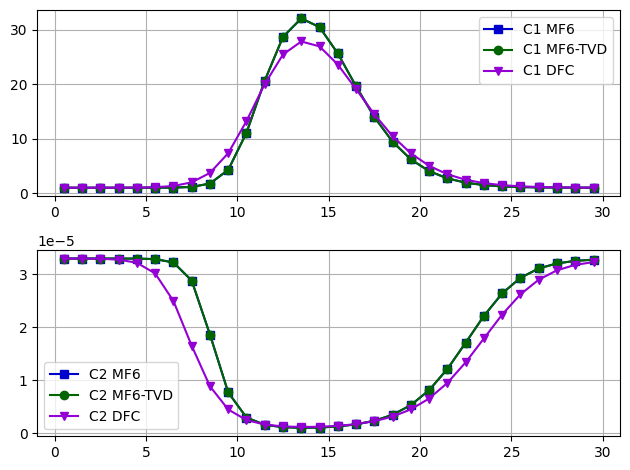

In [9]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(x, wma_mf6_fin[0], "s-", c = "mediumblue", label="C1 MF6")
ax[0].plot(x, wma_tvd_fin[0], "o-", c = "darkgreen" , label="C1 MF6-TVD")
ax[0].plot(x, wma_dfc_fin[0], "v-", c = "darkviolet", label="C1 DFC")
ax[0].grid()
ax[0].legend()

ax[1].plot(x, wma_mf6_fin[1], "s-", c = "mediumblue", label="C2 MF6")
ax[1].plot(x, wma_tvd_fin[1], "o-", c = "darkgreen" , label="C2 MF6-TVD")
ax[1].plot(x, wma_dfc_fin[1], "v-", c = "darkviolet", label="C2 DFC")
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()

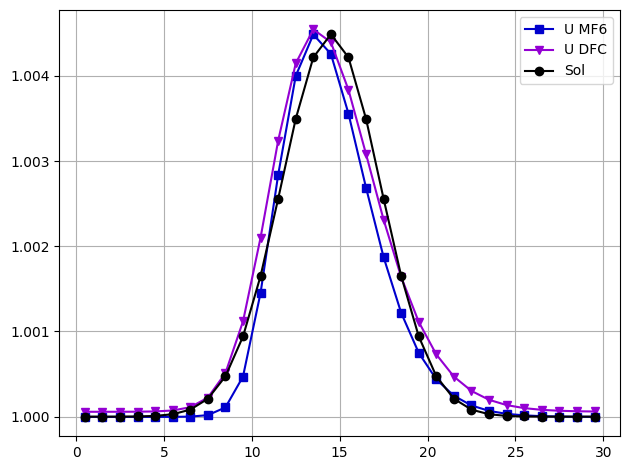

In [7]:
u_exa = u_sol(x)
u_mf6 = np.asarray(wma_mf6_fin[0]) - np.asarray(wma_mf6_fin[1])
u_dfc = np.asarray(wma_dfc_fin[0]) - np.asarray(wma_dfc_fin[1])

u_max = max(u_exa)
u_min = min(u_exa)
u_mf6_max = max(u_mf6)
u_mf6_min = min(u_mf6)
u_dfc_max = max(u_dfc)
u_dfc_min = min(u_dfc)

trans_lin = lambda m, b, x: m * x + b
o_orig = lambda m, x, y: y - m * x

m_mf6 = (u_max - u_min)/(u_mf6_max - u_mf6_min)
o_mf6 = o_orig(m_mf6, u_min, u_mf6_min)

m_dfc = (u_max - u_min)/(u_dfc_max - u_dfc_min)
o_dfc = o_orig(m_dfc, u_min, u_dfc_min)

u_mf6_t = trans_lin(m_mf6, o_mf6, u_mf6)
u_dfc_t = trans_lin(m_dfc, o_dfc, u_dfc)

fig, ax = plt.subplots(1, 1)

ax.plot(x, u_mf6_t, "s-", c = "mediumblue", label="U MF6")
ax.plot(x, u_dfc_t, "v-", c = "darkviolet", label="U DFC")
ax.plot(x, u_exa, "o-", c = "k", label="Sol")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()